# A. Предсказание ошибок [csv файл]

|                     |           |
| ------------------- | ----------|
| Ограничение времени |	20 секунд |
| Ограничение памяти  |	256 Мб    |

## Предсказание ошибок

Нерадивый ML-инженер Тензорослав обучал линейную регрессию на некотором датасете.
Однако, он не был знаком с градиентными методами оптимизации,
поэтому Тензорослав решил искать оптимум с помощью случайного поиска. Для этого
он сгенерировал несколько случайных векторов весов и считал среднеквадратичную
ошибку (MSE) для каждого вектора. Однако в какой-то момент Тензорослав
случайно удалил выборку, на которой он считал MSE.

Помогите Тензорославу закончить начатое и предскажите значение MSE для
тех векторов весов, которые он еще не успел обработать.

## О датасете

Вам предлагаются три файла:

- `train_weights.csv` - содержит значения весов в колонках W0–W9
(10-мерные векторы) и соответствующие значения MSE в колонке MSE
- `test_weights.csv` - содержит тестовые векторы весов (для которых нужно предсказать MSE)
- `example.json` - пример корректной посылки в контест

## Что нужно сделать

Необходимо предсказать колонку MSE для векторов из файла `test_weights.csv` и загрузить файл answers в формате, аналогичном примеру.

### Критерий оценки:

Корень из средней квадратичной логарифмической ошибки (RMSLE).

Баллы рассчитываются по формуле:

`100 * max(min((0.3 - RMSLE) / 0.1, 1), 0)`

Для максимального балла (100) необходимо достичь `RMSLE ≤ 0.2`.

## Требуемый формат вывода

Файл `answers.json` (без пробелов в названии) в формате JSON:

```python
[
    {
        "W0": 0.465,
        "W1": 0.582,
        "W2": 1.071,
        "W3": -1.889,
        "W4": -0.92,
        "W5": -1.084,
        "W6": -1.003,
        "W7": -0.766,
        "W8": -0.858,
        "W9": 0.665,
        "MSE": 40.593
    },
    ...
]
```

## Ответ
Язык
(make) yandexdataschool

In [1]:
import json

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
train_df = pd.read_csv('train_weights.csv')
train_df.head()

,W0,W1,W2,W3,W4,W5,W6,W7,W8,W9,MSE
0,0.355,0.612,0.482,-1.220,-0.412,-0.745,-1.172,-1.760,0.479,1.180,69.113
1,-0.571,0.767,0.537,-0.904,-0.114,0.042,0.739,0.110,-1.743,1.831,67.790
2,0.389,-0.994,-1.537,-0.871,-0.351,-0.679,-0.475,-1.019,0.555,-1.048,32.273
3,0.539,0.679,-1.504,-0.472,0.909,0.158,0.866,1.084,-1.127,-0.436,18.747
4,0.289,-0.284,0.330,1.462,-0.205,0.213,-0.133,-2.064,-0.846,-0.223,62.239


In [3]:
test_df = pd.read_csv('test_weights.csv')
test_df.head()

,W0,W1,W2,W3,W4,W5,W6,W7,W8,W9
0,0.370,-0.424,0.190,-1.882,2.893,-0.070,-1.191,0.521,-0.882,-1.231
1,1.162,-0.310,0.915,-0.297,-0.994,-0.500,0.202,0.508,1.848,1.147
2,1.691,1.329,-0.383,-0.852,-0.576,0.698,0.036,0.442,-0.518,-0.129
3,0.199,1.034,-0.673,1.376,-0.221,-0.256,-0.196,0.217,0.918,-1.259
4,0.005,-0.888,0.049,1.148,-1.260,-1.746,-1.398,-1.417,-0.912,-0.367


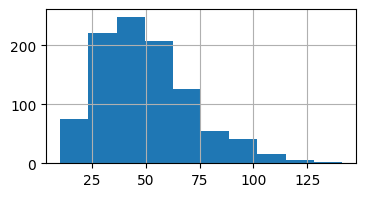

In [4]:
plt.figure(figsize=(4, 2))
train_df['MSE'].hist();

In [5]:
X = train_df[['W0','W1','W2','W3','W4','W5','W6','W7','W8','W9']]
y = train_df['MSE']

## Random Forest

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_log_error
from sklearn.model_selection import cross_val_score

In [7]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Кросс-валидация для оценки качества
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
print(f"CV MSE: {-cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

# Обучение на всех тренировочных данных
model.fit(X_train, y_train)

# Предсказание для тестовых данных
y_pred = model.predict(X_test)

msle = mean_squared_log_error(y_test, y_pred)
rmsle = np.sqrt(msle)
print(rmsle)

CV MSE: 121.969 (+/- 25.655)
0.19632958185578722


In [8]:
# submit 1

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
model.fit(X, y)

mse_preds = model.predict(test_df)

result_list = []
for i, row in test_df.iterrows():
    result_item = row.to_dict()
    result_item['MSE'] = float(mse_preds[i])
    result_list.append(result_item)

with open("answers.json", "w") as f:
    json.dump(result_list, f, indent=4)

## Ridge Regression

In [9]:
import json

import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_log_error
from sklearn.preprocessing import PolynomialFeatures

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Создание полиномиальных признаков 2-й степени
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Обучение Ridge-регрессии
model = Ridge(alpha=1.0)

# Кросс-валидация для оценки качества
cv_scores = cross_val_score(model, X_train_poly, y_train, cv=5, scoring='neg_mean_squared_error')
print(f"CV MSE: {-cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

# Обучение на всех тренировочных данных
model.fit(X_train_poly, y_train)

# Предсказание для тестовых данных
y_pred = model.predict(X_test_poly)

msle = mean_squared_log_error(y_test, y_pred)
rmsle = np.sqrt(msle)
print(rmsle)

CV MSE: 0.001 (+/- 0.000)
0.0006759828103626768


In [11]:
# submit 2

train_df = pd.read_csv('train_weights.csv')
test_df = pd.read_csv('test_weights.csv')

X_train = train_df[['W0', 'W1', 'W2', 'W3', 'W4', 'W5', 'W6', 'W7', 'W8', 'W9']]
y_train = train_df['MSE']

# Создание полиномиальных признаков 2-й степени
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)

# Обучение Ridge-регрессии
model = Ridge(alpha=1.0)
model.fit(X_train_poly, y_train)

X_test = test_df[['W0', 'W1', 'W2', 'W3', 'W4', 'W5', 'W6', 'W7', 'W8', 'W9']]
X_test_poly = poly.transform(X_test)

y_pred = model.predict(X_test_poly)

test_df['MSE'] = y_pred
answers = test_df.to_dict(orient='records')

with open('answers.json', 'w') as f:
    json.dump(answers, f, indent=4)